In [1]:
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import holidays

In [7]:
data = pd.read_excel("data/energy_profile.xlsx", header=2)
data.drop(columns=["Unnamed: 0"], inplace=True)

months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
data_types = ["SA", "FT", "WT"]
new_months = []
for month in months:
  for data_type in data_types:
    new_months.append(month+"_"+data_type)

data.columns = ["Time"] + new_months
data.drop(index=0, inplace=True)
data.dropna(axis=0,subset=["Time"], inplace=True)

data = data.melt(id_vars="Time")

data.columns = ["Time Period", "Date", "value"]
data["month_name"] = data.Date.apply(lambda x: x.split("_")[0])
data["day_type"] = data.Date.apply(lambda x: x.split("_")[1])
data["time"] = data["Time Period"].apply(lambda x: x.split("-")[0])
data["time"] = pd.to_datetime(data["time"], format="%H:%M").dt.time

data.drop(columns=["Date", "Time Period"], inplace=True)


In [20]:
day_map = {
  "Monday": "WT",
  "Tuesday": "WT",
  "Wednesday": "WT",
  "Thursday": "WT",
  "Friday": "WT",
  "Saturday": "SA",
  "Sunday": "FT"
}

de_holidays = holidays.Germany(years=2025)

# 1. Create all 15-minute timestamps for 2025
dt_index = pd.date_range(
    start="2025-01-01 00:00",
    end="2025-12-31 23:45",   # last 15-minute slot of the year
    freq="15min"
)

df = pd.DataFrame({"datetime": dt_index})

# 2. Add date, time, weekday name
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["weekday"] = df["datetime"].dt.day_name() 
df["month_name"] = df["datetime"].dt.month_name()
# df["weekday"] = df["datetime"].dt.day_name(locale="de_DE")  # if you have locale set up
# Name of holiday (or None)
df["holiday_name"] = df["datetime"].dt.date.map(de_holidays.get)

# Boolean flag for “is public holiday?”
df["is_holiday"] = df["holiday_name"].notna()
df["day_type"] = df["weekday"].map(day_map)
df.loc[df["is_holiday"], "day_type"] = "FT"

pd.set_option("display.max_rows", 10)

df = df.merge(
  data,
  on = ["month_name", "day_type", "time"],
  how="left"
).drop(columns=["day_type", "time", "date", "holiday_name", "is_holiday"])

df = df.set_index("datetime")

df_hourly = pd.DataFrame(df.resample("h")["value"].mean()).reset_index()

df_hourly

,datetime,value
0,2025-01-01 00:00:00,14.4835
1,2025-01-01 01:00:00,14.15175
2,2025-01-01 02:00:00,13.97275
3,2025-01-01 03:00:00,13.861
4,2025-01-01 04:00:00,13.95375
...,...,...
8755,2025-12-31 19:00:00,27.46925
8756,2025-12-31 20:00:00,23.03
8757,2025-12-31 21:00:00,20.19275
8758,2025-12-31 22:00:00,17.676


In [9]:
pd.set_option("display.max_rows", 100)
# df[df.value.isna()].tail(40)

In [13]:
df[df.weekday=="Saturday"]["value"].sum()

103038.98000000032

In [14]:
day_ahead = pd.read_csv("data/day_ahead_2025.csv", sep=";")
day_ahead.head(2)

,Start date,End date,Germany/Luxembourg [€/MWh] Original resolutions,∅ DE/LU neighbours [€/MWh] Original resolutions,Belgium [€/MWh] Original resolutions,Denmark 1 [€/MWh] Original resolutions,Denmark 2 [€/MWh] Original resolutions,France [€/MWh] Original resolutions,Netherlands [€/MWh] Original resolutions,Norway 2 [€/MWh] Original resolutions,Austria [€/MWh] Original resolutions,Poland [€/MWh] Original resolutions,Sweden 4 [€/MWh] Original resolutions,Switzerland [€/MWh] Original resolutions,Czech Republic [€/MWh] Original resolutions,DE/AT/LU [€/MWh] Original resolutions,Northern Italy [€/MWh] Original resolutions,Slovenia [€/MWh] Original resolutions,Hungary [€/MWh] Original resolutions
0,"Jan 1, 2025 12:00 AM","Jan 1, 2025 12:15 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25
1,"Jan 1, 2025 12:15 AM","Jan 1, 2025 12:30 AM",2.16,27.99,10.62,2.16,2.54,12.36,13.62,16.35,109.0,15.41,2.67,102.2,21.0,-,138.70,118.46,147.25


In [15]:
day_ahead = day_ahead[["Start date", "End date", "Germany/Luxembourg [€/MWh] Original resolutions", "∅ DE/LU neighbours [€/MWh] Original resolutions"]]

day_ahead.columns = ["start_date", "end_date", "de_price", "neighbour_price"]
day_ahead["start_date"] = pd.to_datetime(day_ahead["start_date"], format="%b %d, %Y %I:%M %p")
day_ahead["end_date"] = pd.to_datetime(day_ahead["end_date"], format="%b %d, %Y %I:%M %p")
day_ahead.head()

,start_date,end_date,de_price,neighbour_price
0,2025-01-01 00:00:00,2025-01-01 00:15:00,2.16,27.99
1,2025-01-01 00:15:00,2025-01-01 00:30:00,2.16,27.99
2,2025-01-01 00:30:00,2025-01-01 00:45:00,2.16,27.99
3,2025-01-01 00:45:00,2025-01-01 01:00:00,2.16,27.99
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.60,29.36


In [22]:
df_combined = df_hourly.merge(
    day_ahead[["start_date", "de_price", "neighbour_price"]],
    left_on="datetime",
    right_on="start_date",
    how="left"
).drop(columns=["start_date"])

df_combined.head()

,datetime,value,de_price,neighbour_price
0,2025-01-01 00:00:00,14.4835,2.16,27.99
1,2025-01-01 01:00:00,14.15175,1.60,29.36
2,2025-01-01 02:00:00,13.97275,0.00,25.86
3,2025-01-01 03:00:00,13.861,-0.01,22.10
4,2025-01-01 04:00:00,13.95375,-0.01,20.38


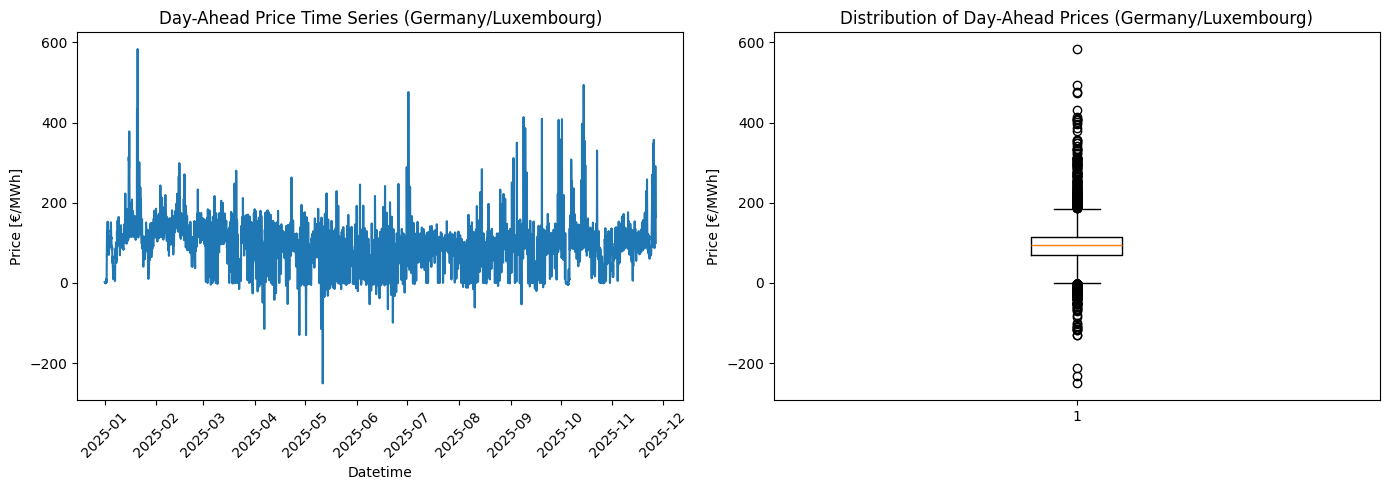

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series plot
axes[0].plot(df_combined["datetime"], df_combined["de_price"])
axes[0].set_title("Day-Ahead Price Time Series (Germany/Luxembourg)")
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("Price [€/MWh]")
for tl in axes[0].get_xticklabels():
  tl.set_rotation(45)

# Boxplot
axes[1].boxplot(df_combined["de_price"].dropna())
axes[1].set_title("Distribution of Day-Ahead Prices (Germany/Luxembourg)")
axes[1].set_ylabel("Price [€/MWh]")

plt.tight_layout()


In [27]:
day_ahead_hourly = pd.DataFrame(df_combined.resample("h", on="datetime")["de_price"].mean()).reset_index()
day_ahead_hourly.head(3)

,datetime,de_price
0,2025-01-01 00:00:00,2.16
1,2025-01-01 01:00:00,1.60
2,2025-01-01 02:00:00,0.00


In [138]:
ANNUAL_USAGE = 2_00_000
SCALE_FACTOR = ANNUAL_USAGE /1_000_000
FLAT_RATE_C_PER_KWH = 30
BATTERY_INEFFICIENCY_FACTOR = 1.2 # The amount of extra electricity we need to store 
ELECTRICITY_SHIFT_PROPORTION = 1.0

# additional costs
NETWORK_USAGE = 8.71
TAX_RATE = 0.19
ELECTRICITY_TAX = 2.05
ADDITIONAL_COST = 1.88
KONZESSION = 1.66
CHP_SURCHARGE = 0.45
COMBINED_ADDITIONAL_COSTS = NETWORK_USAGE + ELECTRICITY_TAX + ADDITIONAL_COST + KONZESSION + CHP_SURCHARGE 

df_usage_and_price = df_hourly.merge(
    day_ahead_hourly,
    on="datetime",
    how="left"
).rename(columns={"de_price": "c_per_kwh_variable", "value": "raw_kwh_usage"})

df_usage_and_price["c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"] / 10 # Convert €/MWh to c€/kWh

# Fill missing prices with average price
df_usage_and_price.loc[df_usage_and_price.c_per_kwh_variable.isna(), "c_per_kwh_variable"] = df_usage_and_price["c_per_kwh_variable"].mean()
df_usage_and_price["scaled_kwh_usage"] = df_usage_and_price["raw_kwh_usage"] * SCALE_FACTOR
df_usage_and_price["c_fixed_costs_kwh"] = COMBINED_ADDITIONAL_COSTS

df_usage_and_price["c_total_variable_cost"] = (
    (df_usage_and_price["scaled_kwh_usage"] * (df_usage_and_price["c_per_kwh_variable"] + df_usage_and_price["c_fixed_costs_kwh"])) * (1 + TAX_RATE)
)

df_usage_and_price["c_per_kwh_flat_rate_cost"] = FLAT_RATE_C_PER_KWH
df_usage_and_price["c_total_flat_cost"] = (df_usage_and_price["c_per_kwh_flat_rate_cost"] * df_usage_and_price["scaled_kwh_usage"]) * (1+TAX_RATE)

df_usage_and_price

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_total_variable_cost,c_per_kwh_flat_rate_cost,c_total_flat_cost
0,2025-01-01 00:00:00,14.4835,0.216000,2.8967,14.75,51.588895,30,103.41219
1,2025-01-01 01:00:00,14.15175,0.160000,2.83035,14.75,50.218617,30,101.043495
2,2025-01-01 02:00:00,13.97275,0.000000,2.79455,14.75,49.051339,30,99.765435
3,2025-01-01 03:00:00,13.861,-0.001000,2.7722,14.75,48.655742,30,98.96754
4,2025-01-01 04:00:00,13.95375,-0.001000,2.79075,14.75,48.981318,30,99.629775
...,...,...,...,...,...,...,...,...
8755,2025-12-31 19:00:00,27.46925,8.913939,5.49385,14.75,154.707299,30,196.130445
8756,2025-12-31 20:00:00,23.03,8.913939,4.606,14.75,129.705365,30,164.4342
8757,2025-12-31 21:00:00,20.19275,8.913939,4.03855,14.75,113.725923,30,144.176235
8758,2025-12-31 22:00:00,17.676,8.913939,3.5352,14.75,99.551543,30,126.20664


In [139]:
df_usage_and_price.c_total_variable_cost.sum(), df_usage_and_price.c_total_flat_cost.sum()

(1413936.470733306, 1790231.5904549991)

In [140]:
def scale_usage_for_shifted_electricity(df, shift_proportion: float):
    df_snippet = df.copy()
    # Thoughts: There's probably only a proportion of one's electricity usage that can be shifted
    df_snippet.loc[:, "shifted_usage_scaled"] = df_snippet["scaled_kwh_usage"].shift(12).fillna(df_snippet["scaled_kwh_usage"].mean())

    original_area = df_snippet["scaled_kwh_usage"].sum()
    shifted_area = df_snippet["shifted_usage_scaled"].sum()
    print(f"shifted_area: {shifted_area:.2f}")
    alpha = original_area / (original_area + shift_proportion * shifted_area)
    shifted_weight = alpha * shift_proportion

    df_snippet["shifted_usage_scaled"] = (df_snippet["shifted_usage_scaled"] * alpha) * 1 # Multiply this for the energy lost
    df_snippet["scaled_kwh_usage"] = df_snippet["scaled_kwh_usage"] * shifted_weight
    df_snippet["combined_shifted_scaled_usage_kwh"] = df_snippet["shifted_usage_scaled"] + df_snippet["scaled_kwh_usage"]

    print(f"combined_shifted_area: {df_snippet['combined_shifted_scaled_usage_kwh'].sum():.2f}")
    
    return df_snippet

In [149]:
def shift_fraction(df, p: float, shift_steps: int = 12):
    df = df.copy()
    base = df["scaled_kwh_usage"]
    shifted = base.shift(shift_steps)

    df["scaled_kwh_usage"] = (1 - p) * base
    df["shifted_usage_scaled"] = p * shifted.fillna(shifted.mean())
    df["combined_shifted_scaled_usage_kwh"] = df["scaled_kwh_usage"] + df["shifted_usage_scaled"]

    print("original:", base.sum())
    print("combined:", df["shifted_usage_scaled"].sum())

    return df

In [150]:
df_temp = df_usage_and_price[(df_usage_and_price["datetime"] >= "2025-02-01") & (df_usage_and_price["datetime"] <= "2025-02-14")]
# df_snippet = scale_usage_for_shifted_electricity(df_temp, ELECTRICITY_SHIFT_PROPORTION)
df_snippet = shift_fraction(df_temp, ELECTRICITY_SHIFT_PROPORTION)

# df_snippet["shifted_usage_scaled"] = df_snippet["shifted_usage"] * BATTERY_INEFFICIENCY_FACTOR

df_snippet["c_total_variable_shifted_cost"] = (
    (df_snippet["combined_shifted_scaled_usage_kwh"] * (df_snippet["c_per_kwh_variable"] + df_snippet["c_fixed_costs_kwh"])) * (1 + TAX_RATE)
)

original: 1956.3646999999978
combined: 1949.7036725913622


/var/folders/lg/qn_p00sn7jzbz4h3vyvl3fcc0000gn/T/ipykernel_10089/2583906381.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["shifted_usage_scaled"] = p * shifted.fillna(shifted.mean())


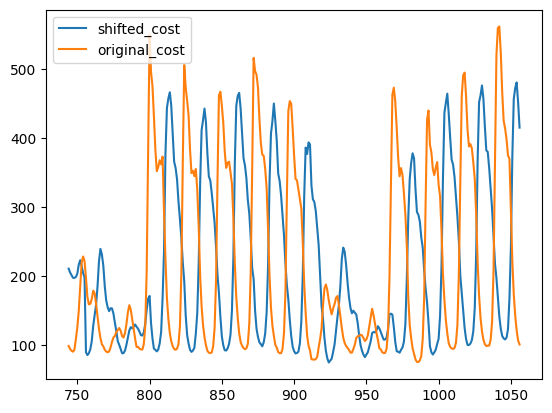

In [153]:
plt.plot(df_snippet["c_total_variable_shifted_cost"], label="shifted_cost")
plt.plot(df_snippet["c_total_variable_cost"], label="original_cost")
plt.legend()

In [155]:
df_snippet.tail(20)

,datetime,raw_kwh_usage,c_per_kwh_variable,scaled_kwh_usage,c_fixed_costs_kwh,c_total_variable_cost,c_per_kwh_flat_rate_cost,c_total_flat_cost,shifted_usage_scaled,combined_shifted_scaled_usage_kwh,c_total_variable_shifted_cost
1037,2025-02-13 05:00:00,19.4315,14.200,0.0,14.75,133.884978,30,138.74091,8.63470,8.6347,297.469732
1038,2025-02-13 06:00:00,28.486,15.999,0.0,14.75,208.468011,30,203.39004,7.06865,7.06865,258.651163
1039,2025-02-13 07:00:00,45.56,19.033,0.0,14.75,366.318528,30,325.2984,5.42650,5.4265,218.154905
1040,2025-02-13 08:00:00,59.18925,22.236,0.0,14.75,521.023317,30,422.611245,4.48710,4.4871,197.492258
1041,2025-02-13 09:00:00,64.04825,22.005,0.0,14.75,560.274236,30,457.304505,3.86175,3.86175,168.906959
...,...,...,...,...,...,...,...,...,...,...,...
1052,2025-02-13 20:00:00,22.4355,17.703,0.0,14.75,173.287629,30,160.18947,11.83785,11.83785,457.166758
1053,2025-02-13 21:00:00,19.30875,16.292,0.0,14.75,142.652968,30,137.864475,12.80965,12.80965,473.188215
1054,2025-02-13 22:00:00,16.9065,15.312,0.0,14.75,120.961882,30,120.71241,13.45030,13.4503,481.168073
1055,2025-02-13 23:00:00,15.63375,13.897,0.0,14.75,106.590689,30,111.624975,13.27605,13.27605,452.579615


In [152]:
df_snippet["c_total_variable_shifted_cost"].sum(), df_snippet["c_total_variable_cost"].sum()

(65462.156107611685, 67737.42682027996)

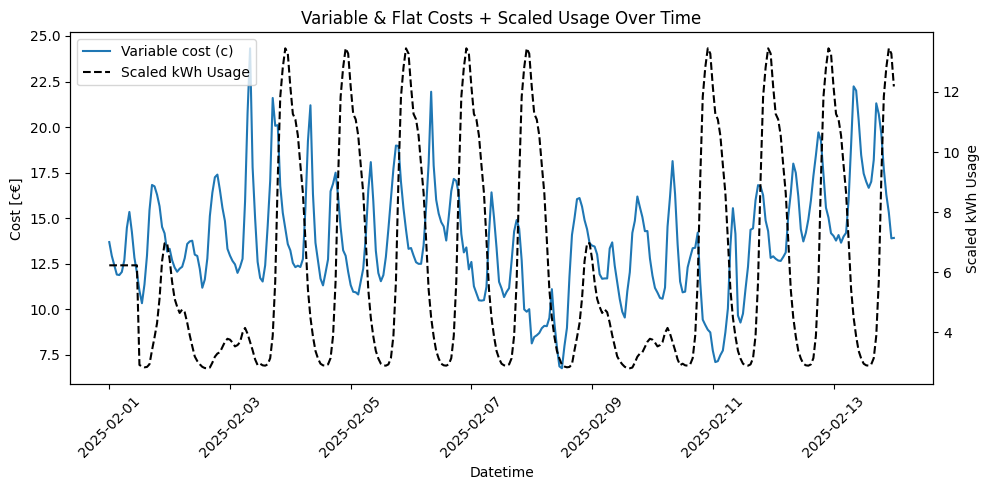

In [158]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# --- Primary axis (left) ---
ax1.plot(df_snippet["datetime"], df_snippet["c_per_kwh_variable"], label="Variable cost (c)")
# ax1.plot(df_snippet["datetime"], df_snippet["c_total_flat_cost"], label="Total Flat Cost")
# ax1.plot(df_snippet["datetime"], df_snippet["shifted_usage"], label="Shifted usage")

ax1.set_xlabel("Datetime")
ax1.set_ylabel("Cost [c€]")
ax1.tick_params(axis='x', rotation=45)

# --- Secondary axis (right) ---
ax2 = ax1.twinx()
ax2.plot(df_snippet["datetime"], df_snippet["combined_shifted_scaled_usage_kwh"], color="black", linestyle="--", label="Scaled kWh Usage")
# ax2.plot(df_snippet["datetime"], df_snippet["shifted_usage"], color="green", linestyle="--", label="Shifted kWh Usage")
ax2.set_ylabel("Scaled kWh Usage")

# --- Combined legend ---
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.title("Variable & Flat Costs + Scaled Usage Over Time")
plt.tight_layout()
plt.show()

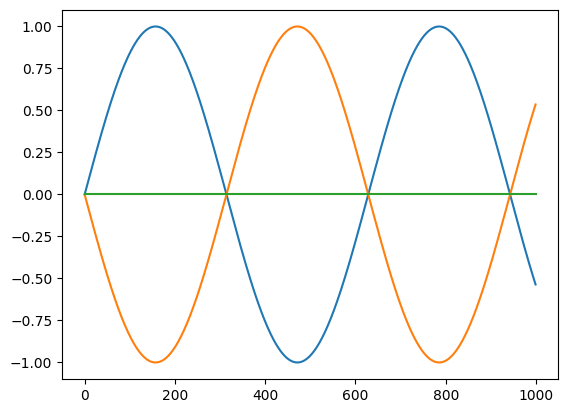

In [74]:
import numpy as np
x1 = np.sin(np.arange(0, 10, 0.01))
x2 = np.sin(np.arange(np.pi, 10+np.pi, 0.01))

x3 = 0.5 * x1 + 0.5 * x2

plt.plot(x1)
plt.plot(x2)
plt.plot(x3)
